# Stage 1. Fingertip/Nail ROI Segmentation

Tidak ada mask ground truth untuk kuku pada dataset ini sehingga stage ini tidak melatih model segmentasi baru seperti U-Net pada konjungtiva. MediaPipe HandLandmarker yang dipakai palm tidak berlaku di sini (diuji langsung pada sampel 60 foto, hanya berhasil pada 1 foto) karena foto adalah close-up satu jari menyentuh permukaan gelap, bukan siluet tangan penuh. Jari disegmentasi memakai thresholding warna kulit YCbCr, bukan Otsu kecerahan, karena tekanan jari pada permukaan gelap menimbulkan pantulan cahaya keputihan yang ikut lolos threshold kecerahan namun tersingkir oleh threshold warna kulit. ROI fingertip/nail kemudian diambil secara geometris dari pita atas mask jari, tanpa segmentasi piksel nail plate terpisah, karena kuku tidak cukup berbeda warna dari kulit sekitarnya untuk disegmentasi langsung. Detail riwayat kesalahan dan perbaikan ada di docs/RENCANA_PIPELINE_KUKU.md. Tidak ada tahap frame-selection terpisah karena input sudah foto statis tunggal, bukan video.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import preprocess
from src.sites.nail import roi as nail_roi

output_dir = paths.outputs_dir("nail")
manifest = pd.read_csv(output_dir / "manifest.csv")
roi_out_dir = output_dir / "roi"
roi_out_dir.mkdir(parents=True, exist_ok=True)
print("total baris manifest", len(manifest))

total baris manifest 803


## Build ROI from Raw Photos

Setiap foto mentah disegmentasi menjadi mask jari, lalu nail plate dideteksi di dalamnya, dan hasil akhir disimpan sebagai PNG RGBA dengan mask pada alpha channel agar langsung kompatibel dengan loader src.common.qc.load_roi tanpa penyesuaian tambahan. Baris yang gagal segmentasi total (foto rusak) dilewati dan dicatat, bukan menghentikan seluruh proses batch.

In [2]:
roi_records = []
failed = []
for _, row in manifest.iterrows():
    rgb = cv2.cvtColor(cv2.imread(row["raw_path"]), cv2.COLOR_BGR2RGB)
    result = nail_roi.build_nail_roi(rgb)
    if result is None:
        failed.append(row["uid"])
        continue
    roi_path = roi_out_dir / f"{row['uid']}.png"
    nail_roi.save_roi_rgba(roi_path, result["rgb"], result["mask"])
    roi_records.append({
        "uid": row["uid"],
        "roi_path": str(roi_path),
        "roi_pixels": int(result["mask"].sum()),
        "finger_area_frac": result["finger_area_frac"],
        "nail_area_frac": result["nail_area_frac"],
        "polish_score": result["polish_score"],
    })

roi_qc = pd.DataFrame(roi_records)
print(f"berhasil {len(roi_qc)} dari {len(manifest)}, gagal segmentasi total: {len(failed)}")
if failed:
    print("contoh gagal:", failed[:8])
roi_qc[["roi_pixels", "finger_area_frac", "nail_area_frac", "polish_score"]].describe().round(4)

berhasil 803 dari 803, gagal segmentasi total: 0


,roi_pixels,finger_area_frac,nail_area_frac,polish_score
count,803.0000,803.0000,803.0000,803.0000
mean,109364.5629,0.2017,0.0122,0.3451
std,14462.0694,0.0356,0.0016,0.0331
min,51571.0000,0.0797,0.0058,0.2469
25%,101299.0000,0.1856,0.0113,0.3227
50%,110423.0000,0.2077,0.0123,0.3435
75%,118998.0000,0.2249,0.0133,0.3657
max,145112.0000,0.2959,0.0162,0.4563


## Nail Polish Flag via IQR

Tidak ada label ground truth cat kuku, sehingga polish_flag ditandai dari outlier statistik pada distribusi polish_score (saturasi rata-rata nail plate) memakai metode IQR standar, bukan ambang tetap yang dikira-kira. Sampel yang ditandai divalidasi visual pada sel berikutnya sebelum dipakai lebih lanjut.

In [3]:
q1, q3 = roi_qc["polish_score"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
roi_qc["polish_flag"] = roi_qc["polish_score"] > upper_bound
print(f"upper bound polish_score: {upper_bound:.4f}")
print(roi_qc["polish_flag"].value_counts().to_string())

upper bound polish_score: 0.4303
polish_flag
False    798
True       5


## Preview Segmentation Stages

Urutan raw foto, mask jari, dan ROI nail plate akhir, untuk verifikasi visual bahwa segmentasi menangkap nail plate tanpa ikut menangkap kulit sekitarnya secara berlebihan. Satu sampel polish_flag juga ditampilkan bila ada, untuk memeriksa apakah penandaan cukup masuk akal secara visual.

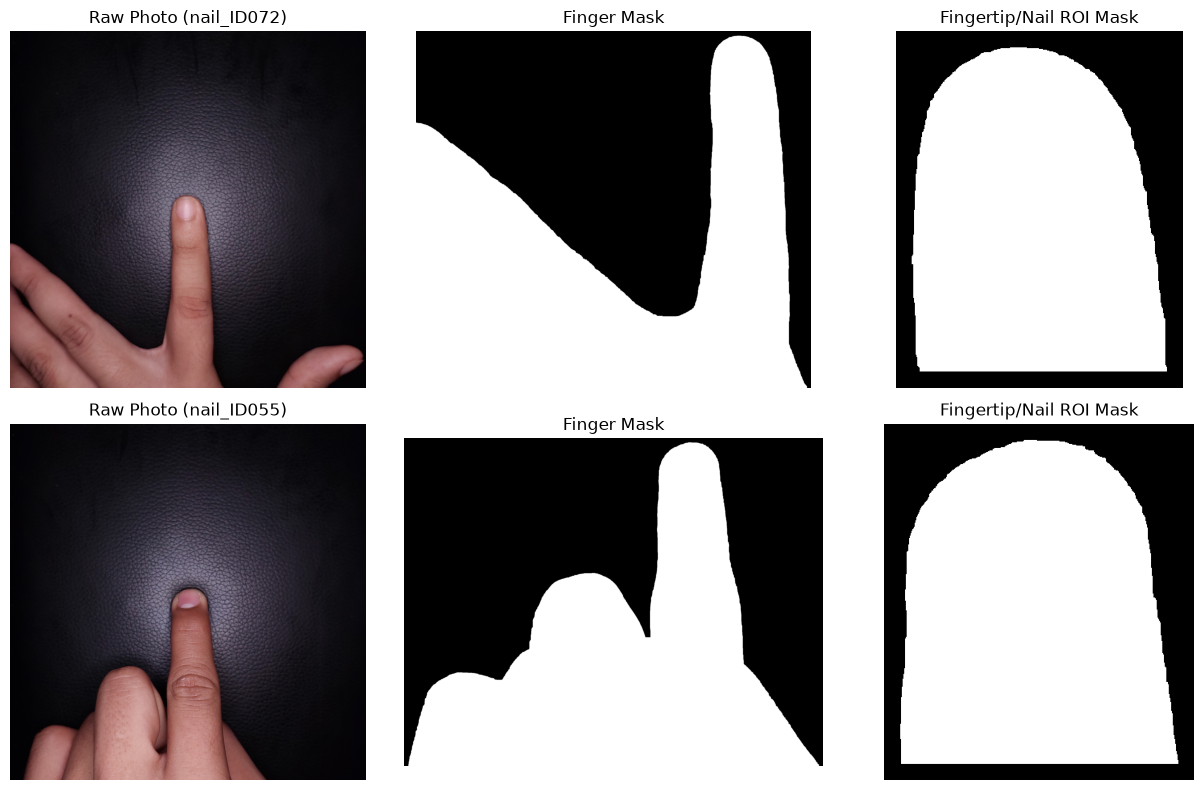

In [4]:
def _preview(uid, ax_row):
    raw_path = manifest.loc[manifest["uid"] == uid, "raw_path"].iloc[0]
    rgb = cv2.cvtColor(cv2.imread(raw_path), cv2.COLOR_BGR2RGB)
    finger_mask = nail_roi.segment_finger(rgb)
    nail_mask_full = nail_roi.detect_nail_plate(finger_mask)
    finger_crop = nail_roi.crop_to_mask(rgb, finger_mask)
    nail_crop = nail_roi.crop_to_mask(rgb, nail_mask_full)
    ax_row[0].imshow(rgb)
    ax_row[0].set_title(f"Raw Photo ({uid})")
    ax_row[1].imshow(finger_crop["mask"], cmap="gray")
    ax_row[1].set_title("Finger Mask")
    ax_row[2].imshow(nail_crop["mask"], cmap="gray")
    ax_row[2].set_title("Fingertip/Nail ROI Mask")
    for ax in ax_row:
        ax.axis("off")


normal_sample = roi_qc.sample(1, random_state=7).iloc[0]["uid"]
samples = [normal_sample]
flagged = roi_qc[roi_qc["polish_flag"]]
if len(flagged) > 0:
    samples.append(flagged.sample(1, random_state=7).iloc[0]["uid"])

fig, axes = plt.subplots(len(samples), 3, figsize=(13, 4 * len(samples)))
axes = np.atleast_2d(axes)
for ax_row, uid in zip(axes, samples):
    _preview(uid, ax_row)
plt.tight_layout()
plt.show()

## Illumination Normalization Check

CLAHE pada channel V dijalankan lewat pipeline generik src.common.preprocess yang sama dengan situs konjungtiva dan palm, memverifikasi bahwa file ROI RGBA hasil stage ini terbaca benar oleh loader bersama.

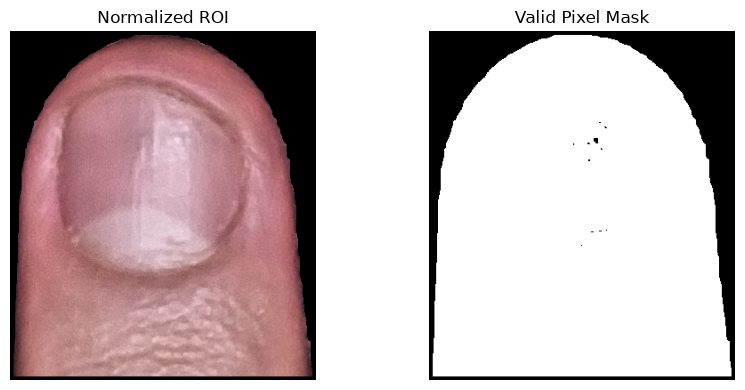

In [5]:
normalized = preprocess.normalize_roi(roi_qc.iloc[0]["roi_path"])
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(normalized["rgb"])
axes[0].set_title("Normalized ROI")
axes[1].imshow(normalized["valid_mask"], cmap="gray")
axes[1].set_title("Valid Pixel Mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Merge ROI into Manifest

Manifest diperbarui dengan roi_path dan polish_flag hasil segmentasi. Baris tanpa ROI (segmentasi gagal total) tetap ada di manifest namun roi_path kosong, sehingga stage berikutnya dapat memfilter otomatis lewat notnull.

In [6]:
manifest = manifest.drop(columns=["roi_path", "polish_flag"], errors="ignore").merge(
    roi_qc[["uid", "roi_path", "polish_flag"]], on="uid", how="left"
)
manifest["roi_path"] = manifest["roi_path"].fillna("")
manifest["polish_flag"] = manifest["polish_flag"].fillna(False)
manifest["roi_precropped"] = manifest["roi_path"] != ""
usable = manifest["roi_precropped"].sum()
print(f"sampel dengan ROI siap pakai: {usable} dari {len(manifest)}")

sampel dengan ROI siap pakai: 803 dari 803


## Save Updated Manifest

In [7]:
manifest.to_csv(output_dir / "manifest.csv", index=False)
roi_qc.to_csv(output_dir / "roi_qc.csv", index=False)
print("manifest dan roi qc tersimpan di", output_dir)

manifest dan roi qc tersimpan di /home/praktikan/projects/Azril/hemavision/outputs/nail
